# 07 - RQ2: Does the backbone change the structure of conflict?

> *Does the backbone change the structure of conflict between tasks, not just
> the accuracy?*  Measured by: learned tau_ij - gate w_ij - cos phi_ij

All 11 QM9 tasks, both backbones. Every figure is saved separately so it can go
on a slide on its own; there is a combined summary panel at the end.

**Which checkpoint for which quantity**

| quantity | checkpoint | why |
|---|---|---|
| cos phi_ij, conflict rate | **LS** | no gradient surgery, so the geometry is the backbone's own |
| w_ij, conflict-vs-tau | **AIM-Matrix** | tau and cos must come from the same model state |
| tau_ij | either | free, straight out of history.json |

**Caveat for the slide:** cos phi_ij was never logged during training
(`train.py` discards it), so everything here is re-measured post-hoc at a single
checkpoint. One seed, 16 batches.

In [21]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt
import common as C
C.apply_style()

TAG      = "11task"
BACKS    = ["Uni-Mol", "GNN"]
K        = 10.0
ANNOTATE = False          # True prints the value in every cell (busy at 11x11)
SHOW_DIFF = False         # True adds a third "Uni-Mol - GNN" panel
SHOW_BAND = False         # True shades the inter-quartile spread on the tau trace
CB_WIDTH  = 0.45          # colourbar length as a fraction of the panel row
SUB      = f"{TAG}/rq2"   # subfolder under notebooks/figures

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load everything

In [22]:
ls_cache  = C.load_cache(TAG, "ls")          # geometry: no intervention
aim_cache = C.load_cache(TAG, "aim_matrix")  # carries tau
tasks = ls_cache[BACKS[0]]["tasks"]
n = len(tasks); off = ~np.eye(n, dtype=bool)

cosM  = {b: ls_cache[b]["cos"].mean(0) for b in BACKS}
freqM = {b: (ls_cache[b]["cos"] < 0).mean(0) for b in BACKS}
tauM  = {b: aim_cache[b]["tau"] for b in BACKS}
wM    = {b: C.aim_weight(aim_cache[b]["cos"], aim_cache[b]["tau"], K).mean(0)
         for b in BACKS}
vsTau = {b: (aim_cache[b]["cos"] < aim_cache[b]["tau"][None]).mean(0)
         for b in BACKS}
traces = {b: C.load_tau_trace(b, TAG) for b in BACKS}

print(f"{TAG}: {n} tasks, {ls_cache[BACKS[0]]['cos'].shape[0]} batches")
for b in BACKS:
    print(f"{b:9s} cos {cosM[b][off].mean():+.4f}   "
          f"conflict(cos<0) {freqM[b][off].mean():.3f}   "
          f"conflict(cos<tau) {vsTau[b][off].mean():.3f}   "
          f"w {wM[b][off].mean():.3f}   "
          f"tau {tauM[b][off].mean():+.4f}")

11task: 11 tasks, 16 batches
Uni-Mol   cos +0.1576   conflict(cos<0) 0.355   conflict(cos<tau) 0.266   w 0.283   tau -0.1881
GNN       cos +0.0307   conflict(cos<0) 0.495   conflict(cos<tau) 0.324   w 0.348   tau -0.2003


## A reusable triptych: Uni-Mol / GNN / difference

In [23]:
def _shrink(cax, frac):
    """Centre a colourbar and cut it to `frac` of its slot width."""
    b = cax.get_position()
    w = b.width * frac
    cax.set_position([b.x0 + (b.width - w) / 2, b.y0, w, b.height])


def triptych(mats, title, cb_label, kind="diverging", lim=None,
             fmt="{:+.2f}", fname=None):
    """Panels side by side with a horizontal colourbar underneath them."""
    order = [b for b in BACKS if b in mats]
    if SHOW_DIFF:
        order_plus = order + ["diff"]
    else:
        order_plus = order
    if lim is None:
        v = max(abs(mats[b][off]).max() for b in order); vmin, vmax = -v, v
    else:
        vmin, vmax = lim
    cm = C.cmap(kind)

    ncol = len(order_plus)
    fig = plt.figure(figsize=(5.2 * ncol, 6.2))
    # rows: heatmaps, then a thin strip for the colourbar(s)
    gs = fig.add_gridspec(2, ncol, height_ratios=[1, .045], hspace=.30,
                          wspace=.28, left=.07, right=.97, top=.78, bottom=.13)

    ims = []
    for i, b in enumerate(order):
        ims.append(C.heatmap(fig.add_subplot(gs[0, i]), mats[b], tasks, cm,
                             vmin, vmax, b, fmt, ANNOTATE,
                             title_loc="center"))

    # colourbar spans the backbone panels only
    cax = fig.add_subplot(gs[1, :len(order)])
    cb = fig.colorbar(ims[0], cax=cax, orientation="horizontal")
    cb.outline.set_visible(False)
    cb.ax.tick_params(length=0, colors="black", labelsize=8)
    cb.set_label(cb_label, color="black", fontsize=9)
    _shrink(cax, CB_WIDTH)

    if SHOW_DIFF:
        diff = mats[order[0]] - mats[order[1]]
        d = abs(diff[off]).max() or .05
        ax = fig.add_subplot(gs[0, len(order)])
        im = C.heatmap(ax, diff, tasks, C.cmap("diverging"), -d, d,
                       f"{order[0]} - {order[1]}", "{:+.2f}", ANNOTATE,
                       title_loc="center")
        cb2 = fig.colorbar(im, cax=fig.add_subplot(gs[1, len(order)]),
                           orientation="horizontal")
        cb2.outline.set_visible(False)
        cb2.ax.tick_params(length=0, colors="black", labelsize=8)
        cb2.set_label("difference", color="black", fontsize=9)
        _shrink(cb2.ax, CB_WIDTH)

    fig.suptitle(title, x=.01, y=.965, ha="left", fontsize=14.5,
                 fontweight="bold", color="black")
    fig.text(.01, .895,
             f"{n} QM9 tasks - n_train={C.N_TRAIN}, seed {C.SEED} - "
             f"{ls_cache[order[0]]['cos'].shape[0]} batches, primary split - "
             "diagonal masked", fontsize=9, color="black", ha="left")
    if fname:
        C.save(fig, fname, SUB)
    return fig

### 1 - cos phi_ij: the raw geometry (LS checkpoint)

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_cosine_11task.png


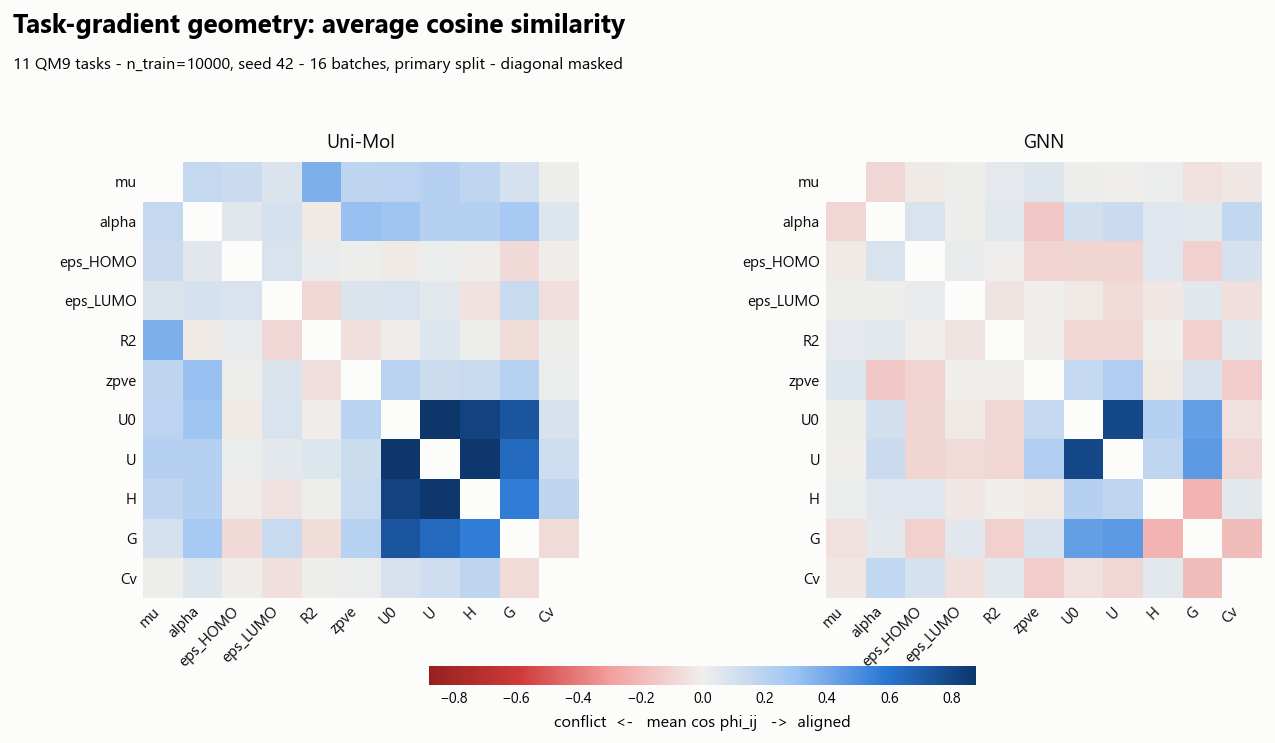

In [24]:
triptych(cosM, "Task-gradient geometry: average cosine similarity",
         "conflict  <-   mean cos phi_ij   ->  aligned",
         fname=f"rq2_cosine_{TAG}")
plt.show()

### 2 - Conflict rate, two definitions

`cos < 0` is sign-based; `cos < tau` is the paper's, measured against the learned threshold.

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_conflict_sign_11task.png


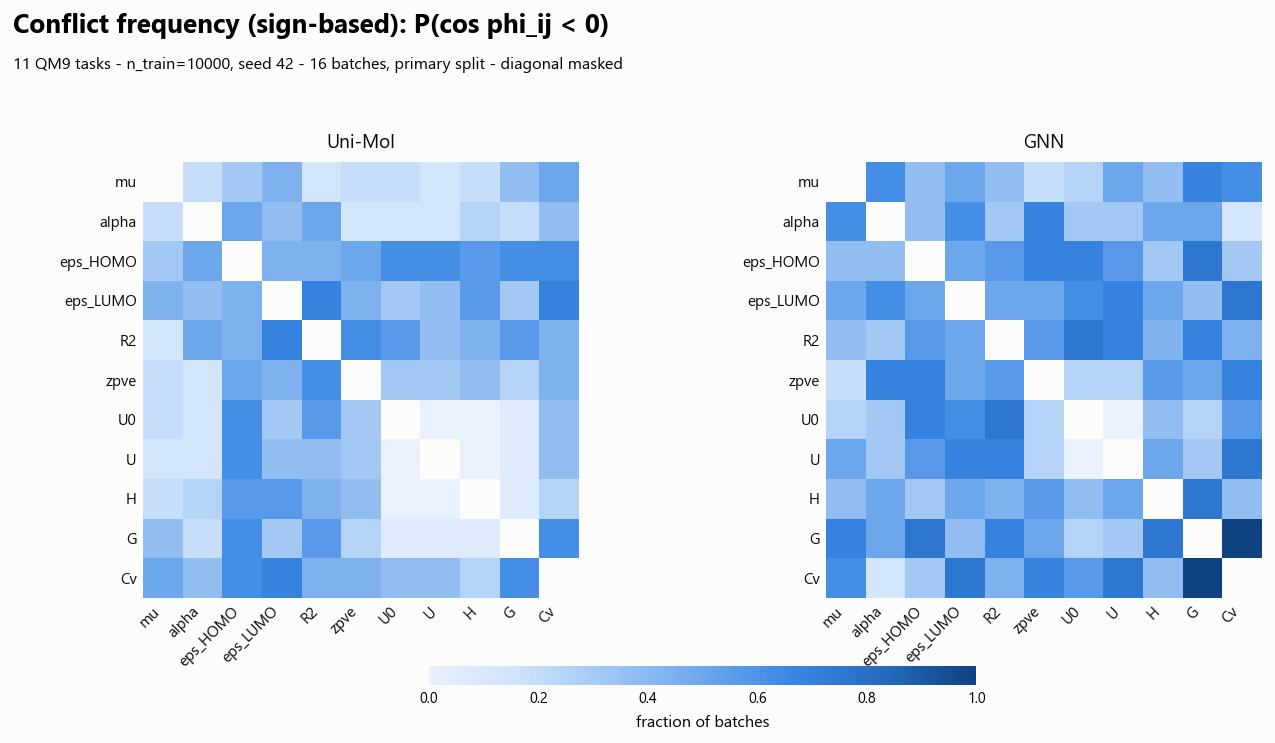

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_conflict_vs_tau_11task.png


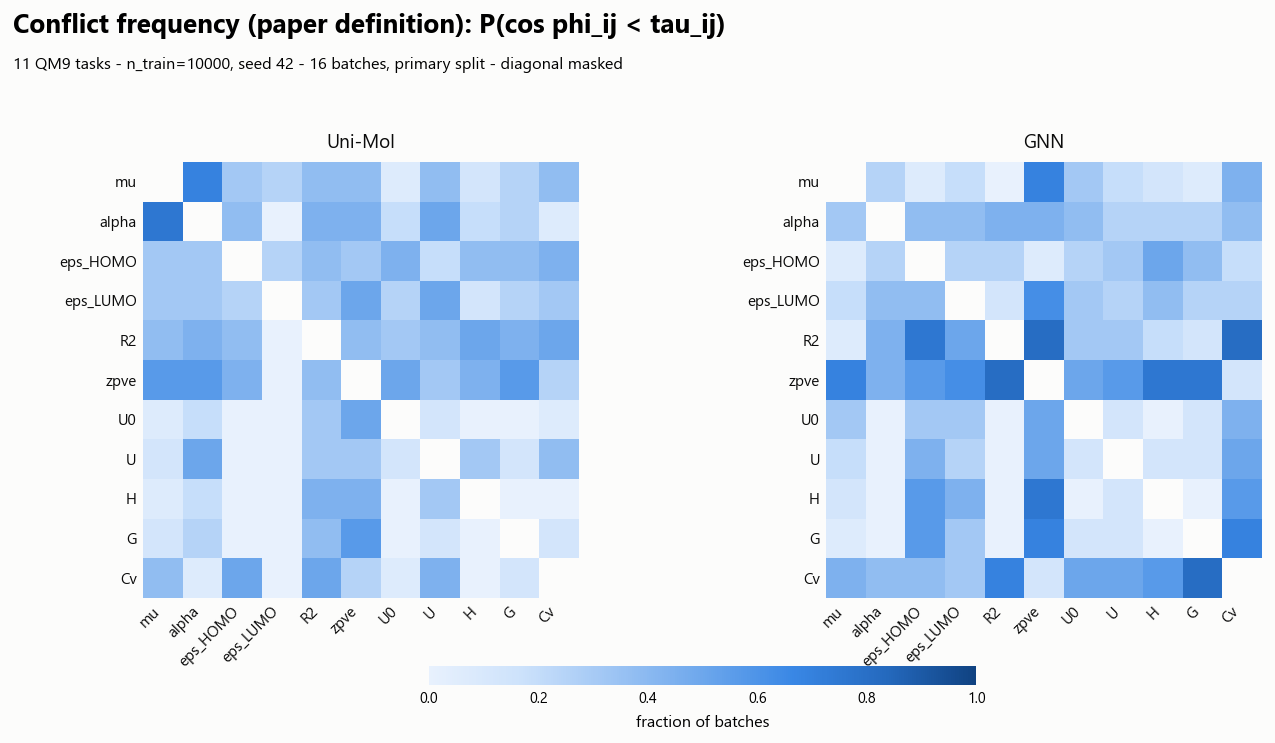

In [25]:
triptych(freqM, "Conflict frequency (sign-based): P(cos phi_ij < 0)",
         "fraction of batches", kind="sequential", lim=(0, 1), fmt="{:.2f}",
         fname=f"rq2_conflict_sign_{TAG}")
plt.show()

triptych(vsTau, "Conflict frequency (paper definition): P(cos phi_ij < tau_ij)",
         "fraction of batches", kind="sequential", lim=(0, 1), fmt="{:.2f}",
         fname=f"rq2_conflict_vs_tau_{TAG}")
plt.show()

### 3 - Learned tau_ij: what the policy decided

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_tau_11task.png


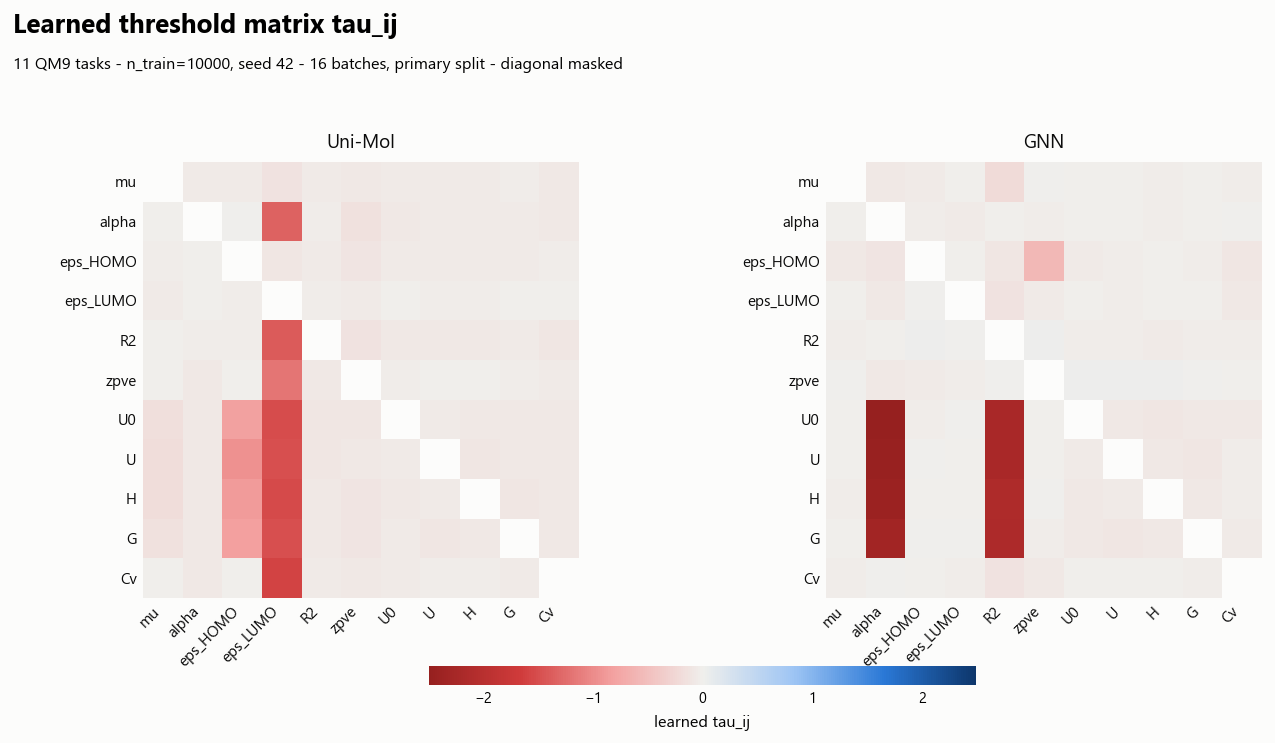

In [26]:
triptych(tauM, "Learned threshold matrix tau_ij", "learned tau_ij",
         fmt="{:+.2f}", fname=f"rq2_tau_{TAG}")
plt.show()

### 4 - Gate w_ij: how hard AIM actually intervenes

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_weight_11task.png


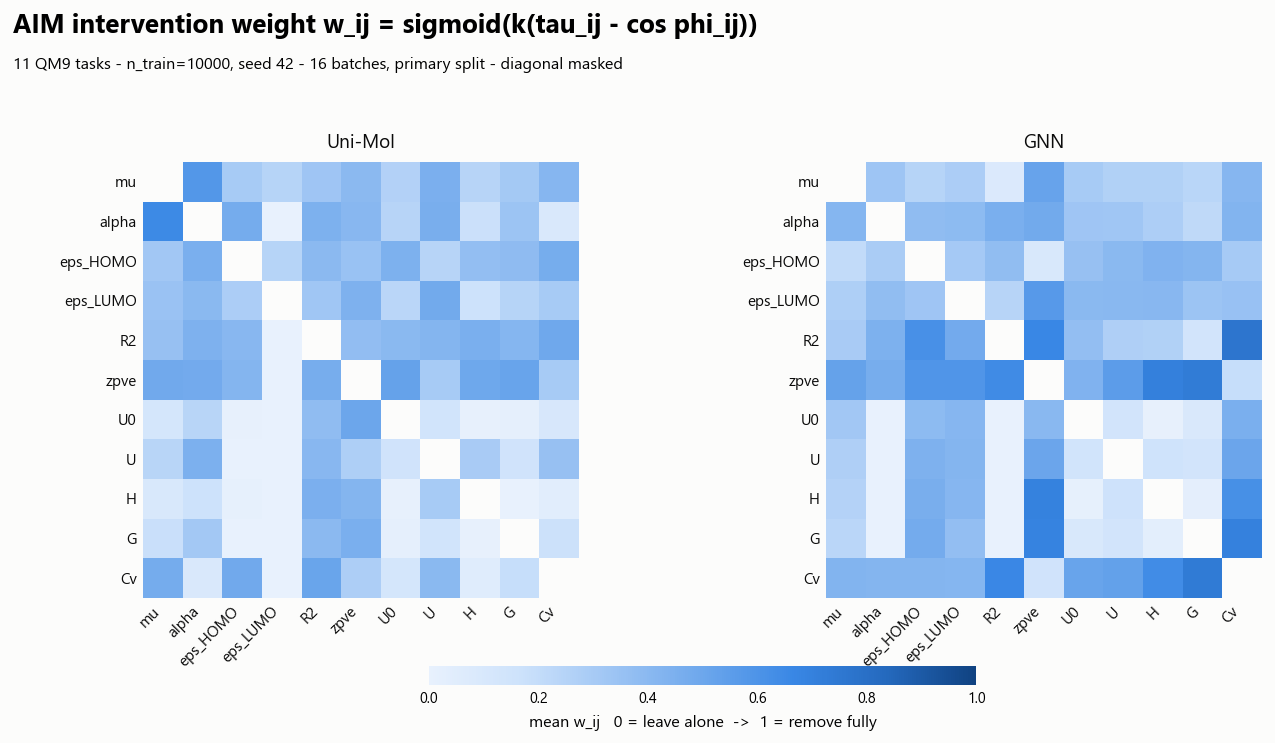

In [27]:
triptych(wM, "AIM intervention weight w_ij = sigmoid(k(tau_ij - cos phi_ij))",
         "mean w_ij   0 = leave alone  ->  1 = remove fully",
         kind="sequential", lim=(0, 1), fmt="{:.2f}", fname=f"rq2_weight_{TAG}")
plt.show()

### 5 - tau over training (free, no measurement)

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_tau_trace_11task.png


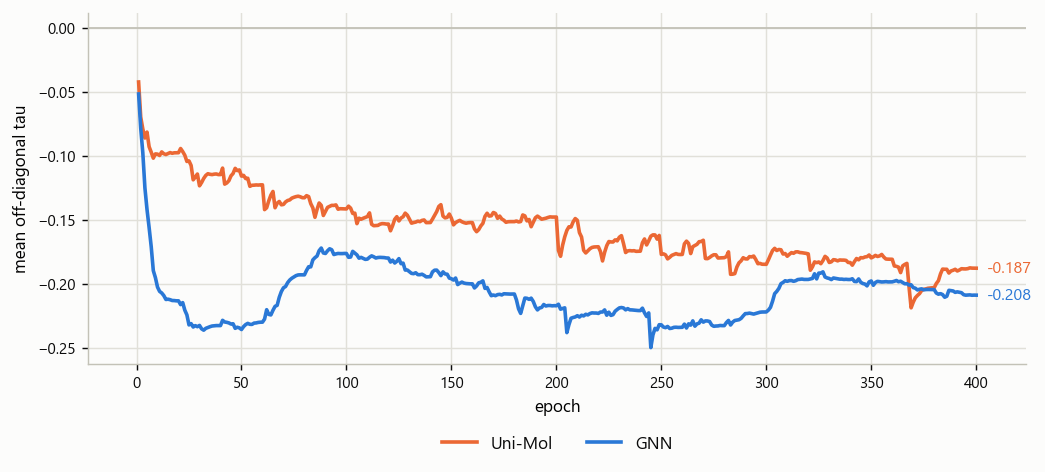

In [35]:
fig, ax = plt.subplots(figsize=(8.2, 5.0))


GNN, UNI = "#2a78d6", "#eb6834"
C.BACKBONE_COLOUR["GNN"] = GNN
C.BACKBONE_COLOUR["Uni-Mol"] = UNI
for b in BACKS:
    t = traces[b]
    if t is None:
        continue
    v = t["tau"][:, off]
    ax.plot(t["epoch"], v.mean(1), color=C.BACKBONE_COLOUR[b], lw=2,
            zorder=3, label=b)
    if SHOW_BAND:
        ax.fill_between(t["epoch"], np.percentile(v, 25, axis=1),
                        np.percentile(v, 75, axis=1),
                        color=C.BACKBONE_COLOUR[b], alpha=.13, lw=0, zorder=2)
    ax.annotate(f"{v.mean(1)[-1]:+.3f}", (t["epoch"][-1], v.mean(1)[-1]),
                textcoords="offset points", xytext=(6, 0), fontsize=9,
                color=C.BACKBONE_COLOUR[b], va="center")
ax.axhline(0, color=C.AXIS, lw=1)
ax.set_xlabel("epoch", color="black"); ax.set_ylabel("mean off-diagonal tau", color="black")
#ax.set_title("Learned threshold over training"
 #            + ("  (band = inter-quartile across pairs)" if SHOW_BAND else ""),
  #           color=C.INK, loc="left", pad=8)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(True, zorder=0); ax.set_axisbelow(True)
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.16),
          ncol=len(BACKS))
ax.margins(x=.06)
fig.subplots_adjust(left=.09, right=.97, top=.80, bottom=.26)
C.save(fig, f"rq2_tau_trace_{TAG}", SUB); plt.show()

### 6 - Summary: the four headline numbers

saved E:\Projects\aim_mtl\notebooks\figures\11task\rq2\rq2_summary_11task.png


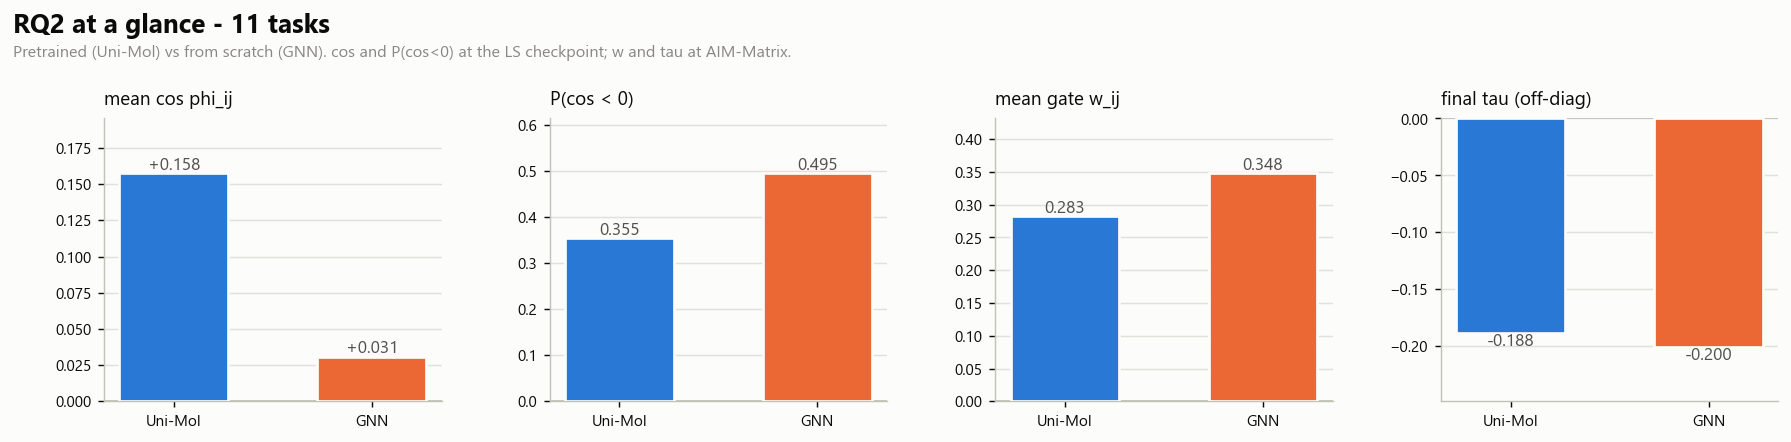

In [29]:
metrics = [("mean cos phi_ij",      {b: cosM[b][off].mean() for b in BACKS}, "{:+.3f}"),
           ("P(cos < 0)",           {b: freqM[b][off].mean() for b in BACKS}, "{:.3f}"),
           ("mean gate w_ij",       {b: wM[b][off].mean() for b in BACKS}, "{:.3f}"),
           ("final tau (off-diag)", {b: tauM[b][off].mean() for b in BACKS}, "{:+.3f}")]

fig, axes = plt.subplots(1, len(metrics), figsize=(3.5 * len(metrics), 3.4))
for ax, (name, vals, fmt) in zip(axes, metrics):
    xs = np.arange(len(BACKS))
    ax.bar(xs, [vals[b] for b in BACKS], .55,
           color=[C.BACKBONE_COLOUR[b] for b in BACKS],
           edgecolor=C.SURFACE, linewidth=1.5, zorder=3)
    for x, b in zip(xs, BACKS):
        ax.text(x, vals[b], fmt.format(vals[b]), ha="center",
                va="bottom" if vals[b] >= 0 else "top",
                fontsize=9.5, color=C.SECONDARY)
    ax.axhline(0, color=C.AXIS, lw=1)
    ax.set_xticks(xs, BACKS)
    ax.set_title(name, color=C.INK, loc="left", pad=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.grid(True, axis="y", zorder=0); ax.set_axisbelow(True); ax.margins(y=.24)
fig.suptitle("RQ2 at a glance - 11 tasks", x=.01, y=1.0, ha="left",
             fontsize=14.5, fontweight="bold", color=C.INK)
fig.text(.01, .90, "Pretrained (Uni-Mol) vs from scratch (GNN). "
         "cos and P(cos<0) at the LS checkpoint; w and tau at AIM-Matrix.",
         fontsize=9, color=C.MUTED, ha="left")
fig.subplots_adjust(left=.06, right=.98, top=.76, bottom=.12, wspace=.32)
C.save(fig, f"rq2_summary_{TAG}", SUB); plt.show()

## How to read this on a slide

**Level.** Uni-Mol's gradients are more aligned and conflict less often than the
GNN's. That is the headline number.

**Structure.** The U0/U/H/G energy block is far more coherent on Uni-Mol, and the
difference panel's large positive cells all sit inside it. Pretraining does not
lift everything uniformly - it pulls physically related tasks into agreement.
That is the part answering "structure, not just accuracy".

**But the policy barely notices.** tau converges to nearly the same value on both
backbones despite the geometries differing. Say this out loud: it is a finding
*and* a limitation of tau as a probe, and it follows from the mechanism -
L_guide contributes no gradient to tau, so tau is shaped only by L_mag and
L_prog, both dominated by gradient norms rather than per-pair geometry.

**The 2-task result points the other way.** With `TAG = "2task"` (once those
caches exist) the mu/eps_LUMO pair conflicts *more* on Uni-Mol. Both are real;
the reading that fits both is that pretraining helps where tasks are genuinely
related and does nothing where they are not. Report it rather than quoting only
the 11-task number.